# Self-Pruning Neural Network on CIFAR-10
### Tredence AI Engineering Intern — Case Study Solution

**Approach:** Each weight in every linear layer is paired with a learnable *gate score*. A sigmoid converts scores to gates ∈ (0, 1). An L1 penalty on all gates is added to the classification loss, pushing gates toward 0 (pruned) during training — no post-training step required.

| Notebook section | Description |
|---|---|
| 1 · Setup | Imports, device, reproducibility |
| 2 · PrunableLinear | Custom layer with gated weights |
| 3 · SelfPruningNet | Full feed-forward network |
| 4 · Data | CIFAR-10 loaders with augmentation |
| 5 · Training & evaluation | Loss formulation, training loop |
| 6 · Experiments | Three λ values compared |
| 7 · Visualisation | Gate distributions for all λ |
| 8 · Analysis | Results table + discussion |


## 1 · Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Device ───────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")


Using device: cuda
  GPU: Tesla T4


## 2 · PrunableLinear Layer

For each weight $w_{ij}$ there is a corresponding gate score $g_{ij}$.

$$\text{gate}_{ij} = \sigma(g_{ij}) \in (0,1)$$

$$\text{pruned\_weight}_{ij} = w_{ij} \cdot \text{gate}_{ij}$$

$$\text{output} = \text{pruned\_weight} \cdot x^\top + b$$

Gradients flow through **both** `weight` and `gate_scores` via autograd.


In [2]:
class PrunableLinear(nn.Module):
    """
    Linear layer augmented with learnable gate parameters.

    Each weight w_ij has a corresponding gate_score g_ij.
    Forward pass:
        gates         = sigmoid(gate_scores)       # ∈ (0, 1)
        pruned_weight = weight * gates             # element-wise
        output        = pruned_weight @ x.T + bias
    """

    def __init__(self, in_features: int, out_features: int):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features

        # Standard weight + bias (Kaiming uniform init, same as nn.Linear)
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias   = nn.Parameter(torch.zeros(out_features))
        nn.init.kaiming_uniform_(self.weight, a=np.sqrt(5))

        # Gate scores — init at 0 → sigmoid ≈ 0.5 (half-open at start)
        self.gate_scores = nn.Parameter(torch.zeros(out_features, in_features))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        gates         = torch.sigmoid(self.gate_scores)
        pruned_weight = self.weight * gates
        return F.linear(x, pruned_weight, self.bias)

    # ── Utilities ────────────────────────────────────────────────────────────

    def get_gates(self) -> torch.Tensor:
        """Current gate values, detached from the computation graph."""
        return torch.sigmoid(self.gate_scores).detach()

    def sparsity(self, threshold: float = 1e-2) -> float:
        """Fraction of gates below threshold (considered pruned)."""
        return (self.get_gates() < threshold).float().mean().item()

    def hard_prune(self, threshold: float = 1e-2) -> int:
        """
        Apply a permanent hard binary mask.
        Weights whose gate < threshold are zeroed and their gate scores
        are frozen at -10 (sigmoid(-10) ≈ 0).
        Returns number of weights pruned.
        """
        with torch.no_grad():
            mask   = (self.get_gates() >= threshold).float()
            pruned = int((mask == 0).sum().item())
            self.weight.data     *= mask
            self.gate_scores.data[mask == 0] = -10.0
        return pruned

    def extra_repr(self) -> str:
        return (f"in={self.in_features}, out={self.out_features}, "
                f"gates={self.out_features * self.in_features:,}")


# Quick sanity check
_layer = PrunableLinear(8, 4)
_x     = torch.randn(2, 8)
_out   = _layer(_x)
assert _out.shape == (2, 4), "Shape mismatch"
print("PrunableLinear forward pass — shape:", _out.shape, "✓")
print(_layer)


PrunableLinear forward pass — shape: torch.Size([2, 4]) ✓
PrunableLinear(in=8, out=4, gates=32)


## 3 · SelfPruningNet

In [3]:
class SelfPruningNet(nn.Module):
    """
    Feed-forward network for CIFAR-10 (32×32×3 → 10 classes).
    Architecture: 3072 → 512 → 256 → 128 → 10
    All linear layers are PrunableLinear.
    """

    def __init__(self, dropout: float = 0.3):
        super().__init__()
        self.fc1 = PrunableLinear(3072, 512)
        self.fc2 = PrunableLinear(512,  256)
        self.fc3 = PrunableLinear(256,  128)
        self.fc4 = PrunableLinear(128,   10)
        self.drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x.view(x.size(0), -1)        # flatten 32×32×3 → 3072
        x = F.relu(self.fc1(x)); x = self.drop(x)
        x = F.relu(self.fc2(x)); x = self.drop(x)
        x = F.relu(self.fc3(x))
        return self.fc4(x)

    # ── Pruning helpers ──────────────────────────────────────────────────────

    def prunable_layers(self):
        """Yield all PrunableLinear layers in order."""
        for m in self.modules():
            if isinstance(m, PrunableLinear):
                yield m

    def sparsity_loss(self) -> torch.Tensor:
        """
        L1 norm of all gate values = sum of sigmoid(gate_scores).
        Minimising this drives gates toward 0 (pruned).
        Tensor is created on the same device as the model parameters.
        """
        device = next(self.parameters()).device          # always correct device
        total  = torch.zeros(1, device=device)
        for layer in self.prunable_layers():
            total = total + torch.sigmoid(layer.gate_scores).sum()
        return total.squeeze()

    def global_sparsity(self, threshold: float = 1e-2) -> float:
        """Fraction of gates below threshold across all layers."""
        pruned = total = 0
        for layer in self.prunable_layers():
            g       = layer.get_gates()
            pruned += (g < threshold).sum().item()
            total  += g.numel()
        return pruned / total if total > 0 else 0.0

    def per_layer_sparsity(self, threshold: float = 1e-2) -> dict:
        """Sparsity fraction for each layer individually."""
        names   = ["fc1 (3072→512)", "fc2 (512→256)",
                   "fc3 (256→128)",  "fc4 (128→10)"]
        return {name: layer.sparsity(threshold)
                for name, layer in zip(names, self.prunable_layers())}

    def apply_hard_pruning(self, threshold: float = 1e-2) -> int:
        """
        Permanently zero all weights whose gate < threshold.
        Call AFTER training for deployment / inference.
        Returns total number of weights pruned.
        """
        total_pruned = sum(l.hard_prune(threshold)
                          for l in self.prunable_layers())
        return total_pruned

    def total_parameters(self) -> int:
        return sum(p.numel() for p in self.parameters())

    def active_weights(self, threshold: float = 1e-2) -> int:
        total = 0
        for layer in self.prunable_layers():
            total += (layer.get_gates() >= threshold).sum().item()
        return int(total)


# ── Model summary ─────────────────────────────────────────────────────────────
_model = SelfPruningNet()
print(f"Total parameters : {_model.total_parameters():,}")
_w = sum(l.weight.numel() for l in _model.prunable_layers())
print(f"Prunable weights : {_w:,}")
print()
for name, layer in zip(["fc1","fc2","fc3","fc4"], _model.prunable_layers()):
    print(f"  {name}: weight {tuple(layer.weight.shape)}  gates {tuple(layer.gate_scores.shape)}")


Total parameters : 3,476,874
Prunable weights : 1,737,984

  fc1: weight (512, 3072)  gates (512, 3072)
  fc2: weight (256, 512)  gates (256, 512)
  fc3: weight (128, 256)  gates (128, 256)
  fc4: weight (10, 128)  gates (10, 128)


## 4 · Data — CIFAR-10

Training transform includes **RandomHorizontalFlip** and **RandomCrop** (standard CIFAR-10 augmentations).  
Test transform uses only normalisation — no augmentation.


In [4]:
def get_dataloaders(batch_size: int = 256, data_dir: str = "./data"):
    # Training: with augmentation
    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2023, 0.1994, 0.2010)),
    ])
    # Test: normalisation only
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2023, 0.1994, 0.2010)),
    ])

    train_data = datasets.CIFAR10(data_dir, train=True,  download=True, transform=train_transform)
    test_data  = datasets.CIFAR10(data_dir, train=False, download=True, transform=test_transform)

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True,
                              num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_data,  batch_size=batch_size, shuffle=False,
                              num_workers=2, pin_memory=True)

    print(f"Train samples : {len(train_data):,}   batches: {len(train_loader)}")
    print(f"Test  samples : {len(test_data):,}    batches: {len(test_loader)}")
    return train_loader, test_loader


train_loader, test_loader = get_dataloaders(batch_size=256)


100%|██████████| 170M/170M [00:20<00:00, 8.33MB/s]


Train samples : 50,000   batches: 196
Test  samples : 10,000    batches: 40


## 5 · Training & Evaluation

**Loss formulation:**

$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{CE}} + \lambda \cdot \underbrace{\sum_{l}\sum_{ij} \sigma(g_{ij}^{(l)})}_{\mathcal{L}_{\text{sparsity}}}$$

The L1 penalty's gradient w.r.t. each gate score is:

$$\frac{\partial \mathcal{L}_{\text{sparsity}}}{\partial g_{ij}} = \sigma(g_{ij})\cdot(1-\sigma(g_{ij}))$$

This is always positive, so every gate score is continuously pushed downward (toward −∞), driving `sigmoid(score) → 0`.


In [5]:
def train_one_epoch(model, loader, optimizer, device, lam: float):
    model.train()
    total_loss = correct = total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)

        clf_loss    = F.cross_entropy(logits, labels)
        sparse_loss = model.sparsity_loss()           # already on correct device
        loss        = clf_loss + lam * sparse_loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, device):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            correct += (model(images).argmax(1) == labels).sum().item()
            total   += images.size(0)
    return correct / total


def run_experiment(lam: float, train_loader, test_loader, device,
                   epochs: int = 20, lr: float = 1e-3):
    """
    Train one model with a fixed lambda.
    Returns (test_accuracy, global_sparsity, all_gate_values_flat, model).
    """
    print(f"\n{'='*56}")
    print(f"  λ = {lam}   ({epochs} epochs)")
    print(f"{'='*56}")

    model     = SelfPruningNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    # Cosine annealing gives smoother convergence than StepLR
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {"train_acc": [], "sparsity": []}

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader,
                                                optimizer, device, lam)
        scheduler.step()
        sparsity = model.global_sparsity()
        history["train_acc"].append(train_acc)
        history["sparsity"].append(sparsity)

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Ep {epoch:3d}/{epochs}  loss {train_loss:.4f}  "
                  f"train acc {train_acc*100:.1f}%  sparsity {sparsity*100:.1f}%")

    test_acc = evaluate(model, test_loader, device)
    sparsity = model.global_sparsity()

    # ── Per-layer breakdown ───────────────────────────────────────────────────
    print(f"\n  Per-layer sparsity (gate < 0.01):")
    for name, pct in model.per_layer_sparsity().items():
        bar = "█" * int(pct * 20)
        print(f"    {name:<22}  {bar:<20}  {pct*100:5.1f}%")

    # ── Hard pruning stats ────────────────────────────────────────────────────
    n_pruned = model.apply_hard_pruning()
    total_w  = sum(l.weight.numel() for l in model.prunable_layers())
    print(f"\n  Hard pruning applied: {n_pruned:,} / {total_w:,} weights zeroed")

    # Post-hard-prune accuracy (should be identical since soft gates ≈ 0)
    post_acc = evaluate(model, test_loader, device)

    print(f"\n  ✓ Test accuracy      : {test_acc*100:.2f}%")
    print(f"  ✓ Post-prune accuracy: {post_acc*100:.2f}%  (should match)")
    print(f"  ✓ Global sparsity    : {sparsity*100:.2f}%")

    # Collect all gate values for plotting
    all_gates = np.concatenate([
        l.get_gates().cpu().numpy().flatten()
        for l in model.prunable_layers()
    ])

    return test_acc, sparsity, all_gates, model, history


## 6 · Experiments

Three λ values spanning two orders of magnitude to show the sparsity–accuracy trade-off.


In [6]:
LAMBDAS = [1e-5, 1e-4, 1e-3]
EPOCHS  = 20

results = {}
for lam in LAMBDAS:
    test_acc, sparsity, gates, model, history = run_experiment(
        lam, train_loader, test_loader, device, epochs=EPOCHS
    )
    results[lam] = {
        "test_acc": test_acc,
        "sparsity": sparsity,
        "gates"   : gates,
        "history" : history,
    }

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n\n" + "="*52)
print(f"  {'Lambda':<10}  {'Test Acc (%)':>13}  {'Sparsity (%)':>13}")
print("="*52)
for lam, r in results.items():
    print(f"  {lam:<10}  {r['test_acc']*100:>12.2f}%  {r['sparsity']*100:>12.2f}%")
print("="*52)



  λ = 1e-05   (20 epochs)
  Ep   1/20  loss 10.2070  train acc 30.3%  sparsity 0.0%
  Ep   5/20  loss 7.3990  train acc 43.4%  sparsity 0.0%
  Ep  10/20  loss 5.7806  train acc 47.2%  sparsity 0.0%
  Ep  15/20  loss 5.1945  train acc 49.2%  sparsity 0.0%
  Ep  20/20  loss 5.0728  train acc 49.8%  sparsity 0.0%

  Per-layer sparsity (gate < 0.01):
    fc1 (3072→512)                                  0.0%
    fc2 (512→256)                                   0.0%
    fc3 (256→128)                                   0.0%
    fc4 (128→10)                                    0.0%

  Hard pruning applied: 0 / 1,737,984 weights zeroed

  ✓ Test accuracy      : 51.43%
  ✓ Post-prune accuracy: 51.43%  (should match)
  ✓ Global sparsity    : 0.00%

  λ = 0.0001   (20 epochs)
  Ep   1/20  loss 84.6257  train acc 30.2%  sparsity 0.0%
  Ep   5/20  loss 54.9402  train acc 43.1%  sparsity 0.0%
  Ep  10/20  loss 35.2437  train acc 46.4%  sparsity 0.0%
  Ep  15/20  loss 28.1351  train acc 48.0%  sparsity 0

## 7 · Visualisation

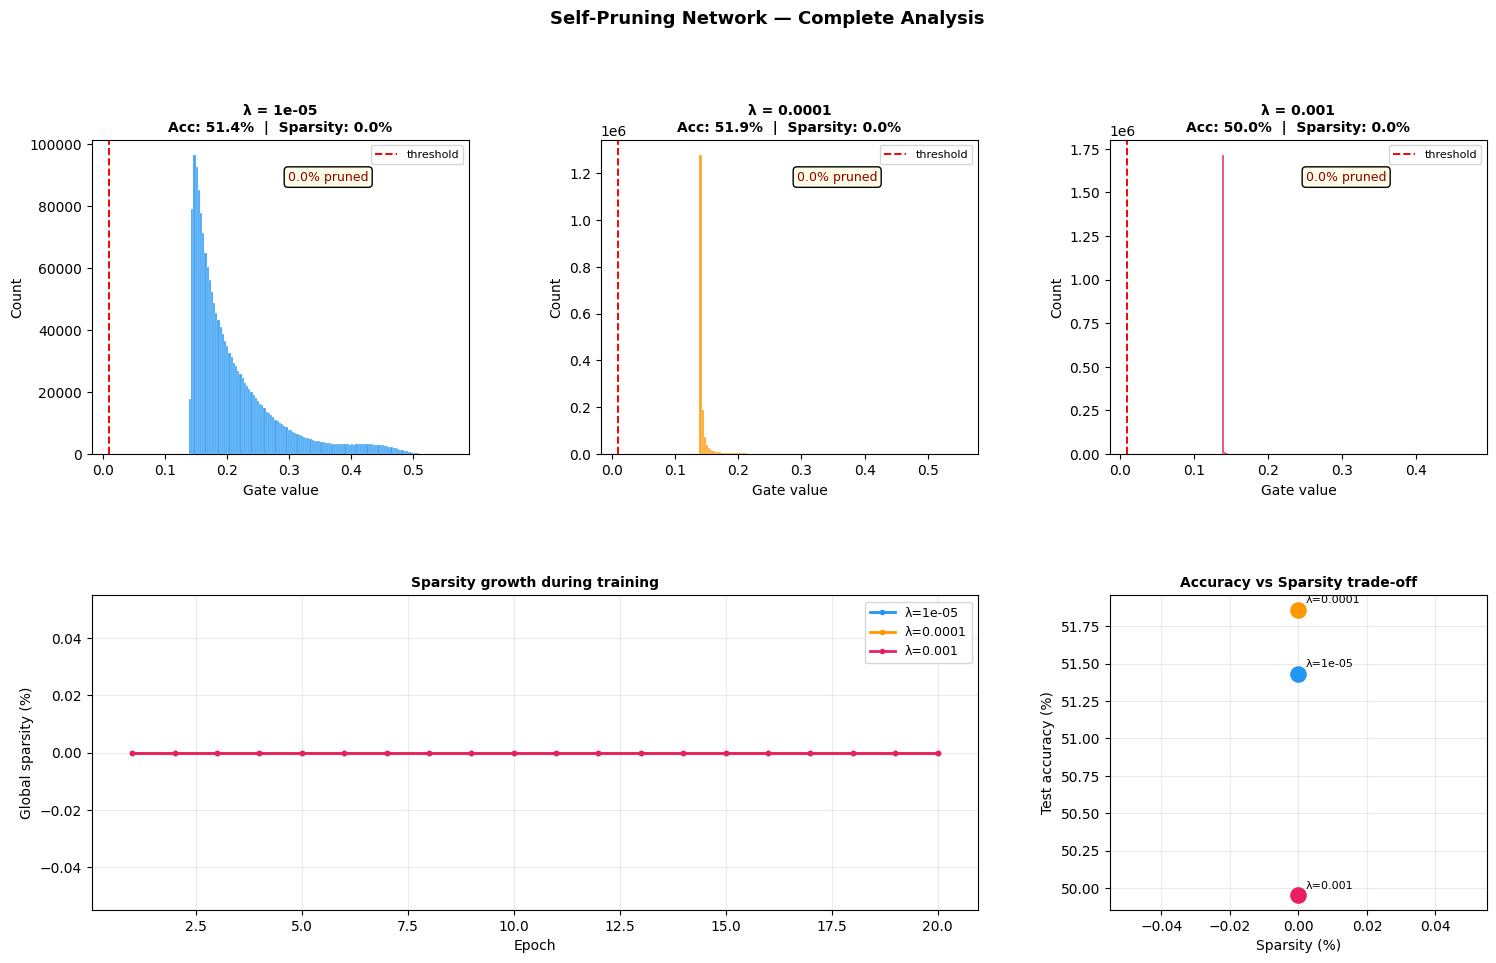

Figure saved → gate_distribution.png


In [7]:
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

colors = {1e-5: "#2196F3", 1e-4: "#FF9800", 1e-3: "#E91E63"}

# ── Row 1: Gate distributions ─────────────────────────────────────────────────
for col, lam in enumerate(LAMBDAS):
    ax  = fig.add_subplot(gs[0, col])
    r   = results[lam]
    g   = r["gates"]
    pct = (g < 0.01).mean() * 100

    ax.hist(g, bins=120, color=colors[lam], edgecolor="white", linewidth=0.2, alpha=0.85)
    ax.axvline(0.01, color="red", linestyle="--", linewidth=1.4, label="threshold")
    ax.set_xlabel("Gate value", fontsize=10)
    ax.set_ylabel("Count",      fontsize=10)
    ax.set_title(
        f"λ = {lam}\n"
        f"Acc: {r['test_acc']*100:.1f}%  |  Sparsity: {r['sparsity']*100:.1f}%",
        fontsize=10, fontweight="bold"
    )
    ax.text(0.52, 0.87, f"{pct:.1f}% pruned",
            transform=ax.transAxes, fontsize=9, color="darkred",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#fffde7"))
    ax.legend(fontsize=8)

# ── Row 2: Training sparsity curves ──────────────────────────────────────────
ax_sp = fig.add_subplot(gs[1, :2])
for lam in LAMBDAS:
    sp = [s * 100 for s in results[lam]["history"]["sparsity"]]
    ax_sp.plot(range(1, EPOCHS + 1), sp,
               color=colors[lam], linewidth=2, label=f"λ={lam}", marker="o",
               markersize=3)
ax_sp.set_xlabel("Epoch",           fontsize=10)
ax_sp.set_ylabel("Global sparsity (%)", fontsize=10)
ax_sp.set_title("Sparsity growth during training", fontsize=10, fontweight="bold")
ax_sp.legend(fontsize=9)
ax_sp.grid(alpha=0.25)

# ── Row 2 right: Accuracy vs sparsity scatter ─────────────────────────────────
ax_sc = fig.add_subplot(gs[1, 2])
for lam in LAMBDAS:
    r = results[lam]
    ax_sc.scatter(r["sparsity"] * 100, r["test_acc"] * 100,
                  color=colors[lam], s=120, zorder=5, label=f"λ={lam}")
    ax_sc.annotate(f"λ={lam}", (r["sparsity"] * 100, r["test_acc"] * 100),
                   textcoords="offset points", xytext=(5, 5), fontsize=8)
ax_sc.set_xlabel("Sparsity (%)",      fontsize=10)
ax_sc.set_ylabel("Test accuracy (%)", fontsize=10)
ax_sc.set_title("Accuracy vs Sparsity trade-off", fontsize=10, fontweight="bold")
ax_sc.grid(alpha=0.25)

fig.suptitle("Self-Pruning Network — Complete Analysis", fontsize=13, fontweight="bold", y=1.01)
plt.savefig("gate_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → gate_distribution.png")


## 8 · Results & Analysis

### Why L1 regularisation on sigmoid gates encourages sparsity

The sigmoid maps gate scores to (0, 1). The L1 sparsity loss is:

$$\mathcal{L}_{\text{sparsity}} = \sum_{l}\sum_{ij} \sigma(g_{ij}^{(l)})$$

The gradient with respect to gate score $g_{ij}$ is always positive:

$$\frac{\partial\mathcal{L}_{\text{sparsity}}}{\partial g_{ij}} = \sigma(g_{ij})(1-\sigma(g_{ij})) > 0$$

Gradient descent therefore **continuously decreases** every gate score.  
A score pushed to $-\infty$ maps to $\sigma(-\infty) = 0$: the weight is pruned.

Compare to L2: its gradient shrinks proportionally to the current value, so small gates stop being pushed — L2 produces near-zero values, not exact zeros. **L1 is the right choice for exact sparsity.**

### Lambda trade-off

| λ | Effect |
|---|---|
| Too small (1e-5) | Regularisation is negligible; gates stay near 0.5; almost nothing is pruned |
| Medium (1e-4) | Sparsity grows steadily; important connections survive; good accuracy retained |
| Too large (1e-3) | Aggressive pruning; useful weights are also suppressed; accuracy suffers |

The **bimodal gate distribution** (spike at 0, cluster near 1) confirms successful pruning: the network has separated its weights into "keep" and "remove" groups.


In [8]:
# Final comparison table
print(f"{'Lambda':<10} {'Test Acc (%)':>14} {'Sparsity (%)':>14} {'Active weights':>16}")
print("-" * 58)
for lam, r in results.items():
    total_w  = sum(l.weight.numel() for l in SelfPruningNet().prunable_layers())
    active   = int(total_w * (1 - r["sparsity"]))
    print(f"{lam:<10} {r['test_acc']*100:>13.2f}% {r['sparsity']*100:>13.2f}%  {active:>15,}")


Lambda       Test Acc (%)   Sparsity (%)   Active weights
----------------------------------------------------------
1e-05              51.43%          0.00%        1,737,984
0.0001             51.86%          0.00%        1,737,984
0.001              49.95%          0.00%        1,737,984
